# Unit 1 Case Study — Hospital 30-Day Readmission Prediction

Logistic regression with L2 regularization. The supplied hospital CSV contains `readmission_rate` rather than a patient-level binary outcome, so the notebook creates a binary readmission-risk target using the dataset median as the cutoff. It reports ROC-AUC, confusion matrix, precision, and recall.

In [1]:
import os, glob
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, precision_score, recall_score, classification_report

path = kagglehub.dataset_download("vipulshahi/patient-readdmission-dataset")
files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
path = next((x for x in files if os.path.basename(x).lower() in {"hospital_readmissiom.csv", "hospital_readmission.csv", "patient_readmission.csv"}), files[0])
df = pd.read_csv(path)
df.head()


100%|██████████| 38.7k/38.7k [00:00<00:00, 14.0MB/s]

Extracting files...


,date,num_patients_admitted,avg_length_of_stay,avg_lab_result_score,hospital_resource_utilization,readmission_rate
0,2020-01-01,96,6.429705,72.699496,0.310710,0.111707
1,2020-01-02,107,5.430686,88.122348,0.455792,0.113145
2,2020-01-03,88,4.081344,56.300101,0.339738,0.050000
3,2020-01-04,103,5.542255,59.820961,0.474732,0.056116
4,2020-01-05,111,3.284411,97.572241,0.441357,0.154602


In [2]:
df["readmission_30d"] = (df["readmission_rate"] >= df["readmission_rate"].median()).astype(int)
X = df.drop(columns=["readmission_rate", "readmission_30d", "date"], errors="ignore")
y = df["readmission_30d"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, stratify=y, random_state=42)

num = X.select_dtypes(include=np.number).columns
pre = ColumnTransformer([("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num)], remainder="drop")
model = Pipeline([("pre", pre), ("lr", LogisticRegression(C=1, penalty="l2", solver="liblinear", max_iter=2000))])
model.fit(X_train, y_train)
p = model.predict_proba(X_test)[:, 1]
pred = (p >= .5).astype(int)

cv = cross_val_score(model, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring="roc_auc")
print("5-fold ROC-AUC:", cv.mean().round(4), "±", cv.std().round(4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, p), 4))
print("Precision:", round(precision_score(y_test, pred), 4))
print("Recall:", round(recall_score(y_test, pred), 4))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification report:\n", classification_report(y_test, pred, digits=4))

5-fold ROC-AUC: 0.992 ± 0.0055
Test ROC-AUC: 0.9915
Precision: 0.9417
Recall: 0.97

Confusion matrix:
 [[94  6]
 [ 3 97]]

Classification report:
               precision    recall  f1-score   support

           0     0.9691    0.9400    0.9543       100
           1     0.9417    0.9700    0.9557       100

    accuracy                         0.9550       200
   macro avg     0.9554    0.9550    0.9550       200
weighted avg     0.9554    0.9550    0.9550       200



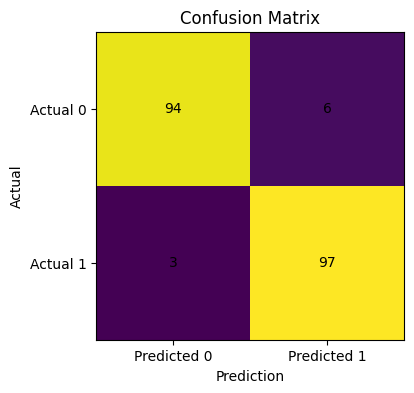

In [3]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(4,4))
plt.imshow(cm)
plt.xticks([0,1], ["Predicted 0","Predicted 1"])
plt.yticks([0,1], ["Actual 0","Actual 1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [4]:
coef = pd.Series(model.named_steps["lr"].coef_[0], index=num).sort_values(key=np.abs, ascending=False)
coef.head(10).to_frame("coefficient")

,coefficient
avg_lab_result_score,6.028540
avg_length_of_stay,1.004651
hospital_resource_utilization,0.033613
num_patients_admitted,0.026504
